In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots


PROJECT_ROOT = next(
    path
    for path in (
        Path.cwd(),
        *Path.cwd().parents,
    )
    if (path / "pyproject.toml").is_file()
)

RUNS_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
)

FIGURE_SIZE = (
    4.5,
    2.8,
)

SEEDS = [
    0,
    1,
    2,
    42,
    123,
]


print("Project root:", PROJECT_ROOT)
print("Runs root:", RUNS_ROOT)
print("Figure size:", FIGURE_SIZE)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
Runs root: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs
Figure size: (4.5, 2.8)


## Training-run manifest

In [2]:
run_rows = []


for seed in SEEDS:
    run_rows.append(
        {
            "family": "nanovision_new_edt",
            "family_label": (
                "NanoVision new EDT"
            ),
            "seed": seed,
            "run_name": (
                f"batch1_seed_{seed}_"
                "optimized_test_no_smoothing"
            ),
            "history_format": "json",
            "history_filename": (
                "history.json"
            ),
        }
    )


    for mode, family_label in [
        (
            "standard",
            "NanoVision standard",
        ),
        (
            "centerness",
            "NanoVision centerness",
        ),
        (
            "edt_LB",
            "NanoVision EDT-LB",
        ),
    ]:
        run_rows.append(
            {
                "family": (
                    f"nanovision_{mode}"
                ),
                "family_label": (
                    family_label
                ),
                "seed": seed,
                "run_name": (
                    f"nanovision_{mode}_"
                    f"stratified_seed_{seed}_"
                    "fresh_100epochs_"
                    "64rays_grid2x2_"
                    "optimized_test_no_smoothing"
                ),
                "history_format": "json",
                "history_filename": (
                    "history.json"
                ),
            }
        )


    run_rows.append(
        {
            "family": "cpsam_v2",
            "family_label": "CPSAM v2",
            "seed": seed,
            "run_name": (
                "cpsam_v2_stratified_seed_"
                f"{seed}_100epochs_best_"
                "validation_optimized"
            ),
            "history_format": "csv",
            "history_filename": (
                "loss_history.csv"
            ),
        }
    )


run_manifest_df = pd.DataFrame(
    run_rows
)


run_manifest_df[
    "history_path"
] = run_manifest_df.apply(
    lambda row: (
        RUNS_ROOT
        / row["run_name"]
        / "train"
        / row["history_filename"]
    ),
    axis=1,
)


print(
    "Training runs:",
    len(run_manifest_df),
)

print(
    "Families:",
    run_manifest_df[
        "family"
    ].nunique(),
)

display(
    run_manifest_df
)

Training runs: 25
Families: 5


,family,family_label,seed,run_name,history_format,history_filename,history_path
0,nanovision_new_edt,NanoVision new EDT,0,batch1_seed_0_optimized_test_no_smoothing,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
1,nanovision_standard,NanoVision standard,0,nanovision_standard_stratified_seed_0_fresh_10...,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
2,nanovision_centerness,NanoVision centerness,0,nanovision_centerness_stratified_seed_0_fresh_...,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
3,nanovision_edt_LB,NanoVision EDT-LB,0,nanovision_edt_LB_stratified_seed_0_fresh_100e...,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
4,cpsam_v2,CPSAM v2,0,cpsam_v2_stratified_seed_0_100epochs_best_vali...,csv,loss_history.csv,c:\Users\abd93000\PycharmProjects\cnt_project_...
5,nanovision_new_edt,NanoVision new EDT,1,batch1_seed_1_optimized_test_no_smoothing,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
6,nanovision_standard,NanoVision standard,1,nanovision_standard_stratified_seed_1_fresh_10...,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
7,nanovision_centerness,NanoVision centerness,1,nanovision_centerness_stratified_seed_1_fresh_...,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
8,nanovision_edt_LB,NanoVision EDT-LB,1,nanovision_edt_LB_stratified_seed_1_fresh_100e...,json,history.json,c:\Users\abd93000\PycharmProjects\cnt_project_...
9,cpsam_v2,CPSAM v2,1,cpsam_v2_stratified_seed_1_100epochs_best_vali...,csv,loss_history.csv,c:\Users\abd93000\PycharmProjects\cnt_project_...


## Load training and validation losses

In [4]:
def load_training_history(
    row,
):
    history_path = Path(
        row["history_path"]
    )


    if row["history_format"] == "json":
        history = json.loads(
            history_path.read_text(
                encoding="utf-8"
            )
        )

        training_loss = np.asarray(
            history["loss"],
            dtype=float,
        )

        validation_loss = np.asarray(
            history["val_loss"],
            dtype=float,
        )

        epochs = np.arange(
            1,
            len(training_loss) + 1,
        )


    elif row["history_format"] == "csv":
        history = pd.read_csv(
            history_path
        )

        epochs = pd.to_numeric(
            history["epoch"],
            errors="raise",
        ).to_numpy(dtype=int)

        training_loss = pd.to_numeric(
            history["train_loss"],
            errors="raise",
        ).to_numpy(dtype=float)

        validation_loss = pd.to_numeric(
            history[
                "validation_loss"
            ],
            errors="raise",
        ).to_numpy(dtype=float)


    else:
        raise ValueError(
            "Unsupported history format: "
            f"{row['history_format']}"
        )


    if not (
        len(epochs)
        == len(training_loss)
        == len(validation_loss)
    ):
        raise RuntimeError(
            f"{row['run_name']}: history "
            "arrays have different lengths."
        )


    return pd.DataFrame(
        {
            "family": row["family"],
            "family_label": (
                row["family_label"]
            ),
            "seed": int(
                row["seed"]
            ),
            "run_name": (
                row["run_name"]
            ),
            "history_format": (
                row["history_format"]
            ),
            "history_path": str(
                history_path
            ),
            "epoch": epochs,
            "training_loss": (
                training_loss
            ),
            "validation_loss": (
                validation_loss
            ),
        }
    )

In [5]:
history_tables = []


for _, row in (
    run_manifest_df.iterrows()
):
    history_tables.append(
        load_training_history(
            row
        )
    )


training_history_df = pd.concat(
    history_tables,
    ignore_index=True,
)


print(
    "History rows:",
    len(training_history_df),
)

print(
    "Loaded runs:",
    training_history_df[
        "run_name"
    ].nunique(),
)

print(
    "Loaded families:",
    training_history_df[
        "family"
    ].nunique(),
)

display(
    training_history_df.head()
)

History rows: 2424
Loaded runs: 25
Loaded families: 5


,family,family_label,seed,run_name,history_format,history_path,epoch,training_loss,validation_loss
0,nanovision_new_edt,NanoVision new EDT,0,batch1_seed_0_optimized_test_no_smoothing,json,c:\Users\abd93000\PycharmProjects\cnt_project_...,1,6.115225,5.345995
1,nanovision_new_edt,NanoVision new EDT,0,batch1_seed_0_optimized_test_no_smoothing,json,c:\Users\abd93000\PycharmProjects\cnt_project_...,2,4.966650,4.343055
2,nanovision_new_edt,NanoVision new EDT,0,batch1_seed_0_optimized_test_no_smoothing,json,c:\Users\abd93000\PycharmProjects\cnt_project_...,3,4.927432,4.670365
3,nanovision_new_edt,NanoVision new EDT,0,batch1_seed_0_optimized_test_no_smoothing,json,c:\Users\abd93000\PycharmProjects\cnt_project_...,4,4.578671,3.840818
4,nanovision_new_edt,NanoVision new EDT,0,batch1_seed_0_optimized_test_no_smoothing,json,c:\Users\abd93000\PycharmProjects\cnt_project_...,5,3.975894,3.856998


## Validate loaded histories

In [6]:
history_validation_df = (
    training_history_df
    .groupby(
        [
            "family",
            "family_label",
            "seed",
            "run_name",
            "history_format",
        ],
        as_index=False,
    )
    .agg(
        epoch_count=(
            "epoch",
            "nunique",
        ),
        first_epoch=(
            "epoch",
            "min",
        ),
        last_epoch=(
            "epoch",
            "max",
        ),
        training_loss_min=(
            "training_loss",
            "min",
        ),
        training_loss_final=(
            "training_loss",
            "last",
        ),
        validation_loss_min=(
            "validation_loss",
            "min",
        ),
        validation_loss_final=(
            "validation_loss",
            "last",
        ),
    )
)


finite_losses = np.isfinite(
    training_history_df[
        [
            "training_loss",
            "validation_loss",
        ]
    ].to_numpy(dtype=float)
).all()


if not finite_losses:
    raise RuntimeError(
        "Some loss values are nonfinite."
    )


if (
    history_validation_df[
        "run_name"
    ].nunique()
    != 25
):
    raise RuntimeError(
        "Expected 25 loaded runs."
    )


nanovision_validation = (
    history_validation_df.loc[
        history_validation_df[
            "family"
        ].ne("cpsam_v2")
    ]
)

if not nanovision_validation[
    "epoch_count"
].eq(100).all():
    raise RuntimeError(
        "Some NanoVision histories do not "
        "contain 100 epochs."
    )


cpsam_validation = (
    history_validation_df.loc[
        history_validation_df[
            "family"
        ].eq("cpsam_v2")
    ]
)


print(
    "PASS: all histories contain finite "
    "training and validation losses."
)

print()
print("Epoch counts by run:")

display(
    history_validation_df[
        [
            "family_label",
            "seed",
            "epoch_count",
            "validation_loss_min",
            "validation_loss_final",
        ]
    ]
)

PASS: all histories contain finite training and validation losses.

Epoch counts by run:


,family_label,seed,epoch_count,validation_loss_min,validation_loss_final
0,CPSAM v2,0,83,0.292498,0.293215
1,CPSAM v2,1,100,0.266390,0.266398
2,CPSAM v2,2,92,0.257248,0.257733
3,CPSAM v2,42,72,0.217817,0.220201
4,CPSAM v2,123,77,0.275899,0.277210
5,NanoVision centerness,0,100,2.707407,2.957938
6,NanoVision centerness,1,100,2.458455,2.597971
7,NanoVision centerness,2,100,2.449340,2.661412
8,NanoVision centerness,42,100,2.266456,2.436910
9,NanoVision centerness,123,100,2.490536,2.767520


## Training and validation loss curves by model family


In [14]:
import matplotlib
import scienceplots

from matplotlib.lines import Line2D


FAMILY_ORDER = [
    "nanovision_new_edt",
    "nanovision_standard",
    "nanovision_centerness",
    "nanovision_edt_LB",
    "cpsam_v2",
]

FAMILY_LABELS = {
    "nanovision_new_edt": (
        "EDT-SYM"
    ),
    "nanovision_standard": (
        "EDT"
    ),
    "nanovision_centerness": (
        "SYM"
    ),
    "nanovision_edt_LB": (
        "EDT-LB"
    ),
    "cpsam_v2": (
        "CPSAM v2"
    ),
}

SEED_COLORS = {
    0: "#0072B2",
    1: "#E69F00",
    2: "#009E73",
    42: "#CC79A7",
    123: "#D55E00",
}



## Best checkpoint epochs
The checkpoint epoch is identified as the epoch with the
minimum validation loss for every model family and split.

In [15]:
best_checkpoint_indices = (
    training_history_df
    .groupby(
        [
            "family",
            "seed",
        ]
    )["validation_loss"]
    .idxmin()
)


best_checkpoint_df = (
    training_history_df.loc[
        best_checkpoint_indices,
        [
            "family",
            "family_label",
            "seed",
            "run_name",
            "epoch",
            "training_loss",
            "validation_loss",
        ],
    ]
    .rename(
        columns={
            "epoch": "best_checkpoint_epoch",
            "training_loss": (
                "training_loss_at_checkpoint"
            ),
            "validation_loss": (
                "minimum_validation_loss"
            ),
        }
    )
    .sort_values(
        [
            "family",
            "seed",
        ]
    )
    .reset_index(drop=True)
)


display(
    best_checkpoint_df
)

,family,family_label,seed,run_name,best_checkpoint_epoch,training_loss_at_checkpoint,minimum_validation_loss
0,cpsam_v2,CPSAM v2,0,cpsam_v2_stratified_seed_0_100epochs_best_vali...,68,0.273134,0.292498
1,cpsam_v2,CPSAM v2,1,cpsam_v2_stratified_seed_1_100epochs_best_vali...,98,0.266891,0.266390
2,cpsam_v2,CPSAM v2,2,cpsam_v2_stratified_seed_2_100epochs_best_vali...,77,0.263411,0.257248
3,cpsam_v2,CPSAM v2,42,cpsam_v2_stratified_seed_42_100epochs_best_val...,57,0.265526,0.217817
4,cpsam_v2,CPSAM v2,123,cpsam_v2_stratified_seed_123_100epochs_best_va...,62,0.275598,0.275899
5,nanovision_centerness,NanoVision centerness,0,nanovision_centerness_stratified_seed_0_fresh_...,65,2.070011,2.707407
6,nanovision_centerness,NanoVision centerness,1,nanovision_centerness_stratified_seed_1_fresh_...,74,1.934514,2.458455
7,nanovision_centerness,NanoVision centerness,2,nanovision_centerness_stratified_seed_2_fresh_...,71,2.070046,2.449340
8,nanovision_centerness,NanoVision centerness,42,nanovision_centerness_stratified_seed_42_fresh...,70,1.951143,2.266456
9,nanovision_centerness,NanoVision centerness,123,nanovision_centerness_stratified_seed_123_fres...,32,2.557339,2.490536


## Training and validation loss curves by model family

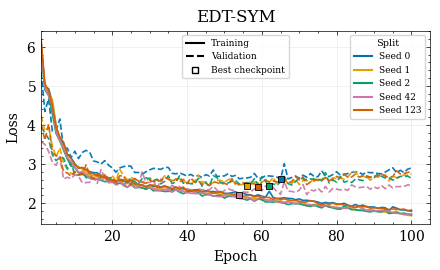

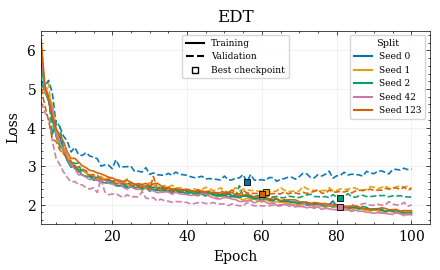

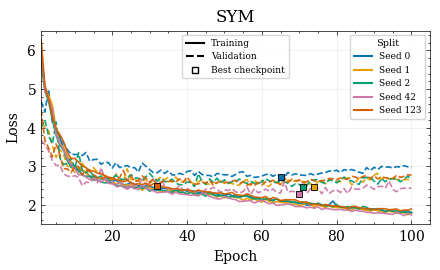

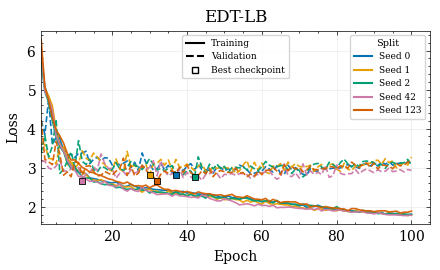

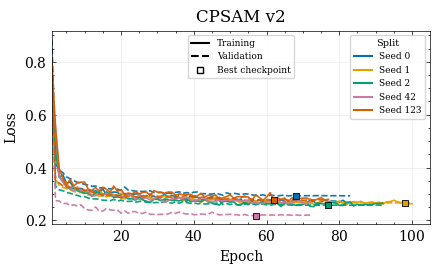

Training-loss figures created: 5


In [16]:
from matplotlib.lines import Line2D


training_loss_figures = {}


for family in FAMILY_ORDER:
    family_table = (
        training_history_df.loc[
            training_history_df[
                "family"
            ].eq(family)
        ]
    )

    family_checkpoints = (
        best_checkpoint_df.loc[
            best_checkpoint_df[
                "family"
            ].eq(family)
        ]
        .set_index("seed")
    )


    with plt.style.context(
        [
            "science",
            "no-latex",
        ]
    ):
        figure, axis = plt.subplots(
            figsize=FIGURE_SIZE,
        )


        for seed in SEEDS:
            seed_table = (
                family_table.loc[
                    family_table[
                        "seed"
                    ].eq(seed)
                ]
                .sort_values("epoch")
            )

            if seed_table.empty:
                raise RuntimeError(
                    f"Missing history for "
                    f"{family}, seed {seed}."
                )

            if seed not in family_checkpoints.index:
                raise RuntimeError(
                    f"Missing checkpoint for "
                    f"{family}, seed {seed}."
                )


            color = SEED_COLORS[seed]


            axis.plot(
                seed_table["epoch"],
                seed_table[
                    "training_loss"
                ],
                color=color,
                linestyle="-",
                linewidth=1.2,
                alpha=0.95,
            )

            axis.plot(
                seed_table["epoch"],
                seed_table[
                    "validation_loss"
                ],
                color=color,
                linestyle="--",
                linewidth=1.2,
                alpha=0.95,
            )


            checkpoint_row = (
                family_checkpoints.loc[
                    seed
                ]
            )

            axis.scatter(
                checkpoint_row[
                    "best_checkpoint_epoch"
                ],
                checkpoint_row[
                    "minimum_validation_loss"
                ],
                marker="s",
                s=24,
                facecolor=color,
                edgecolor="black",
                linewidth=0.6,
                zorder=5,
            )


        axis.set_title(
            FAMILY_LABELS[family]
        )

        axis.set_xlabel(
            "Epoch"
        )

        axis.set_ylabel(
            "Loss"
        )

        axis.set_xlim(
            left=1,
        )

        axis.grid(
            alpha=0.25,
        )


        seed_handles = [
            Line2D(
                [0],
                [0],
                color=SEED_COLORS[seed],
                linewidth=1.5,
                label=f"Seed {seed}",
            )
            for seed in SEEDS
        ]

        loss_type_handles = [
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="-",
                linewidth=1.5,
                label="Training",
            ),
            Line2D(
                [0],
                [0],
                color="black",
                linestyle="--",
                linewidth=1.5,
                label="Validation",
            ),
            Line2D(
                [0],
                [0],
                marker="s",
                linestyle="none",
                markerfacecolor="white",
                markeredgecolor="black",
                markersize=5,
                label="Best checkpoint",
            ),
        ]


        seed_legend = axis.legend(
            handles=seed_handles,
            title="Split",
            fontsize=6.5,
            title_fontsize=7,
            loc="upper right",
            frameon=True,
        )

        axis.add_artist(
            seed_legend
        )

        axis.legend(
            handles=loss_type_handles,
            fontsize=6.5,
            loc="upper center",
            frameon=True,
        )


        figure.tight_layout()


    training_loss_figures[
        family
    ] = figure

    plt.show()


print(
    "Training-loss figures created:",
    len(training_loss_figures),
)